# Raster Agent DEM Workflow

This notebook demonstrates a streaming GAS workflow focused on the `raster_agent`.

Workflow:

1. Download DEM data for Centre County, Pennsylvania using `geospatial_data_retrieval_agent` and OpenTopography.
2. Use `raster_agent` to run several DEM raster operations.
3. Display GeoTIFF outputs inline as quick raster previews.


## Install GAS Client SDK

This notebook uses the published `gas-client` package from PyPI. Run this cell once in a new notebook environment.


In [1]:
%pip install -q gas-client


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import numpy as np
import requests
from dotenv import load_dotenv
import rasterio
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

examples_dir = project_root / "examples_for_using_gas_services"
artifact_dir = examples_dir / "downloaded_gas_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)


from gas_client import GasClient


## User Settings

In [4]:
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "http://127.0.0.1:4042"
# server_url = "https://www.geospatial-agentic-services.online"

openai_api_key = os.getenv("OPENAI_API_KEY")

default_credentials = {}
if openai_api_key:
    default_credentials["OPENAI_API_KEY"] = openai_api_key
if not default_credentials:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

opentopography_key = os.getenv("OPENTOPOGRAPHY_API_KEY")
if not opentopography_key:
    raise RuntimeError("Set OPENTOPOGRAPHY_API_KEY in the repo .env file before running this notebook.")

poll_timeout = 2400


## Create Client and Agents

In [5]:
client = GasClient(server_url, default_credentials=default_credentials)

retrieval_agent = client.agent("geospatial_data_retrieval_agent")
geospatial_data_inspection_agent = client.agent("geospatial_data_inspection_agent")
raster_agent = client.agent("raster_agent")
raster_agent.status()

{'status': 'available',
 'agent_id': 'raster_agent',
 'service_base': '/agents/raster_agent',
 'data_directory': 'D:\\GAS\\Data\\raster_agent'}

## 1. Download DEM Data for Centre County, PA

This request asks the retrieval agent to use OpenTopography and return a GeoTIFF DEM. The bounding box keeps the request focused on Centre County.


In [6]:
dem_task = retrieval_agent.run_streaming_task(
    (
        "Download a DEM GeoTIFF for Centre County, Pennsylvania from OpenTopography "
    ),
    artifact_delivery="URL",
    credentials={
        "source_credentials": {
            "OpenTopography": {
                "key": opentopography_key,
            }
        }
    },
    timeout=poll_timeout,
)

[20:45:17] stream_connected: Streaming connection established.
[20:45:17] Geospatial Data Retrieval Agent: I received your request.
[20:45:17] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:45:17] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[20:45:18] task_accepted: Task accepted. Starting streaming execution.
[20:45:18] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[20:45:18] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[20:45:19] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[20:45:19] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[20:45:19] Geospatial Data Retrieval Agent: I am comp

In [7]:
client.print_artifacts(dem_task)

Artifacts: 1
1. Dataset
   role             : dataset_path
   format           : tif
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-0757-qznd-8132.tif
   original_filename: download_a_744530.tif
   size_bytes       : 9097019
   url              : http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-0757-qznd-8132.tif


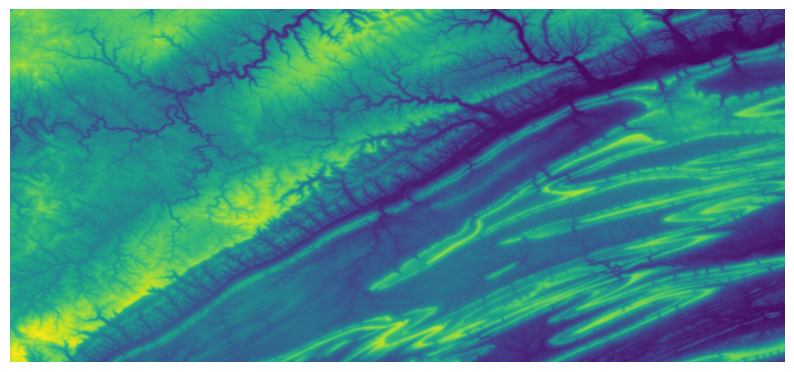

In [8]:
client.display_artifacts(dem_task)

In [12]:
dem_url = client.get_artifact_urls(dem_task)[0]


## 2. Raster Agent: Hillshade

In [17]:
hillshade_instructions = (
    "Create a hillshade GeoTIFF from this DEM. Use the DEM elevation band, preserve the raster CRS "
    "and affine transform, set nodata outside valid DEM cells, and return one float32 or uint8 GeoTIFF. "
    "Use azimuth 315 degrees and altitude 45 degrees. Register the output as a georeferenced raster artifact."
)

hillshade_task = raster_agent.run_streaming_task(
    hillshade_instructions,
    input_datasets=[dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)


[20:50:32] stream_connected: Streaming connection established.
[20:50:32] Raster Agent: I received your request.
[20:50:32] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:50:32] Raster Agent: I found the required credentials and can start the model-backed workflow.
[20:50:32] task_accepted: Task accepted. Starting streaming execution.
[20:50:33] Raster Agent: Next I will start the workflow with the prepared inputs.
[20:50:33] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[20:50:33] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[20:50:36] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[20:50:37] Raster

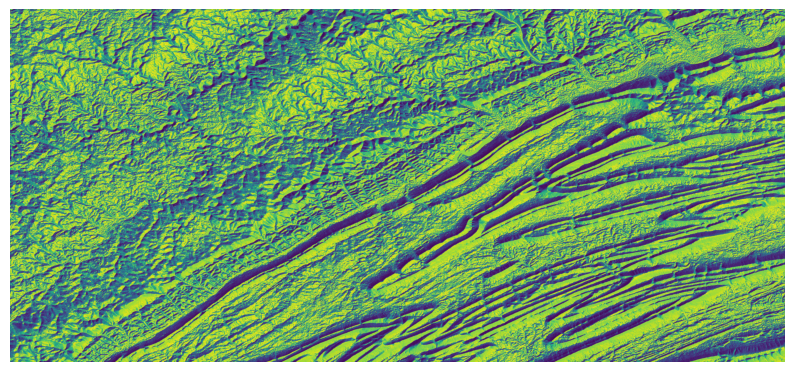

In [20]:
hillshade_url = client.get_artifact_urls(hillshade_task)[0]
client.display_artifacts(hillshade_task)
 

## 3. Raster Agent: Slope in Degrees

In [21]:
slope_instructions = (
    "Create a slope raster in degrees from this DEM. Use the raster pixel size from the affine transform. "
    "Preserve the source CRS and affine transform. Set nodata outside valid DEM cells. "
    "Return one georeferenced float32 GeoTIFF artifact."
)
slope_task = raster_agent.run_streaming_task(
    slope_instructions,
    input_datasets=[dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)


[20:52:40] stream_connected: Streaming connection established.
[20:52:40] Raster Agent: I received your request.
[20:52:40] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:52:40] Raster Agent: I found the required credentials and can start the model-backed workflow.
[20:52:40] task_accepted: Task accepted. Starting streaming execution.
[20:52:40] Raster Agent: Next I will start the workflow with the prepared inputs.
[20:52:41] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[20:52:41] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[20:52:43] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[20:52:43] Raster

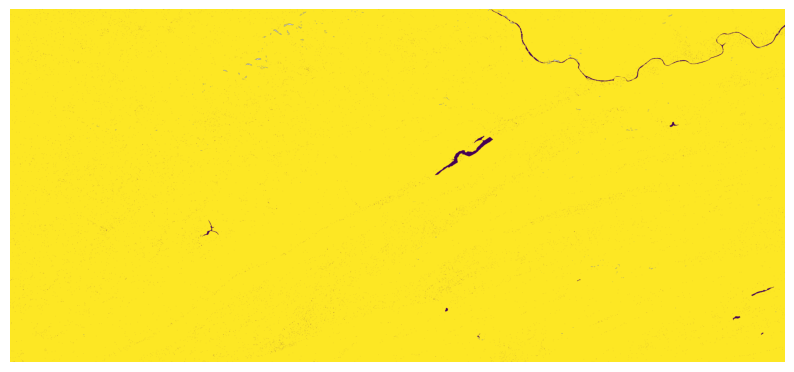

In [23]:
client.display_artifacts(slope_task)

## 4. Raster Agent: Elevation Classes

In [24]:
elevation_classes_instructions = (
    "Reclassify the DEM elevation values into 5 equal-interval elevation classes. "
    "Use class values 1 through 5 and nodata value 0. Preserve CRS and affine transform. "
    "Return one georeferenced int16 GeoTIFF artifact."
)

elevation_classes_task = raster_agent.run_streaming_task(
    elevation_classes_instructions,
    input_datasets=[dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)


[20:53:33] stream_connected: Streaming connection established.
[20:53:33] Raster Agent: I received your request.
[20:53:33] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:53:33] Raster Agent: I found the required credentials and can start the model-backed workflow.
[20:53:33] task_accepted: Task accepted. Starting streaming execution.
[20:53:34] Raster Agent: Next I will start the workflow with the prepared inputs.
[20:53:34] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[20:53:34] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[20:53:34] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[20:53:34] Raster

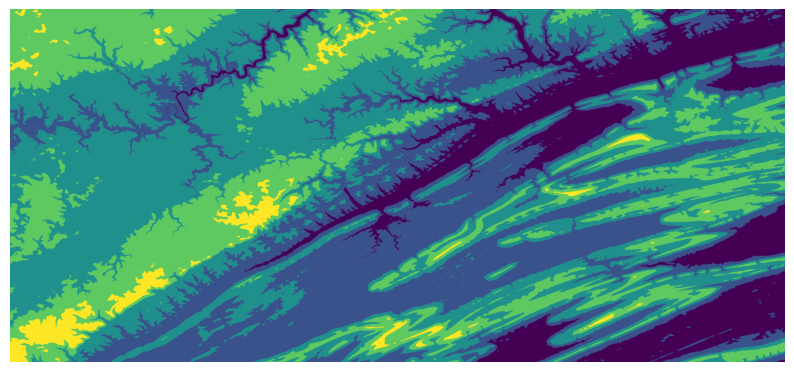

In [25]:
client.display_artifacts(elevation_classes_task)

## 7. Raster Agent: High-Elevation Mask

In [27]:
high_elevation_instructions = (
    "Create a binary high-elevation mask from this DEM. Mark pixels above the 80th percentile of valid elevation as 1, "
    "all other valid pixels as 0, and nodata pixels as 255. Preserve CRS and affine transform. "
    "Return one georeferenced uint8 GeoTIFF artifact."
)
high_elevation_task = raster_agent.run_streaming_task(
    high_elevation_instructions,
    input_datasets=[dem_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)

[20:54:14] stream_connected: Streaming connection established.
[20:54:14] Raster Agent: I received your request.
[20:54:14] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[20:54:14] Raster Agent: I found the required credentials and can start the model-backed workflow.
[20:54:14] task_accepted: Task accepted. Starting streaming execution.
[20:54:14] Raster Agent: Next I will start the workflow with the prepared inputs.
[20:54:15] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[20:54:15] Raster Agent: I am planning the next raster processing step and deciding whether to execute code or register the final artifact. This is iteration 1.
[20:54:17] Raster Agent: I will execute Python raster processing code in the sandbox to load, inspect, transform, or analyze the dataset.
[20:54:17] Raster

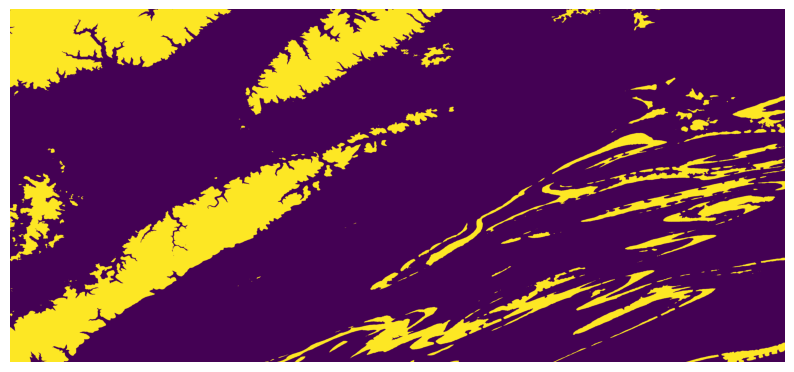

In [28]:
client.display_artifacts(high_elevation_task)